## Importing libraries

In [ ]:
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt

## Getting image paths

In [ ]:
train_data_path = './Images/Train'
test_data_path = './Images/Test/'

train_images_path = os.path.join(train_data_path, 'Images')
train_masks_path = os.path.join(train_data_path, 'Masks')

test_images_path = os.path.join(test_data_path, 'Images')
test_masks_path = os.path.join(test_data_path, 'Masks')

image_names = os.listdir(train_images_path)
test_image_names = os.listdir(test_images_path)

train_images = [os.path.join(train_images_path, image_name) for image_name in image_names]
train_masks = [os.path.join(train_masks_path, image_name) for image_name in image_names]

test_images = [os.path.join(test_images_path, image_name) for image_name in test_image_names]
test_masks = [os.path.join(test_masks_path, image_name) for image_name in test_image_names]

example_mask = tf.keras.utils.load_img(train_masks[0])
example_mask

## Loading training data

In [ ]:
X_train = []
y_train = []

for i in range(0, 4000):
    img = tf.keras.utils.load_img(train_images[i])
    img = tf.keras.utils.img_to_array(img)
    X_train.append(img)

    mask = tf.keras.utils.load_img(train_masks[i], color_mode='grayscale')
    mask = tf.keras.utils.img_to_array(mask)
    y_train.append(mask)

    if i%100 == 0 or i==len(train_images):
        print(f"\r{i}/{len(train_images)} images loaded...", end='')

## Loading test data

In [ ]:
X_test = []
y_test = []

for i in range(0, 2000):
    img = tf.keras.utils.load_img(test_images[i])
    img = tf.keras.utils.img_to_array(img)
    X_test.append(img)

    mask = tf.keras.utils.load_img(test_masks[i], color_mode='grayscale')
    mask = tf.keras.utils.img_to_array(mask)
    y_test.append(mask)

    if i%100 == 0 or i==len(test_images):
        print(f"\r{i}/{len(test_images)} images loaded...", end='')

y_test_scaled = np.array(y_test)/255.

In [ ]:
X_train = np.array(X_train)
y_train = np.array(y_train)
y_train_scaled = y_train/255.

X_train.shape, y_train.shape, np.unique(y_train[0])

## Defining Model architecture and Compiling the model

In [ ]:
def encoder_block(input_, filters):
    out1 = tf.keras.layers.Conv2D(filters=filters, kernel_size=(3, 3), padding='same', activation='relu')(input_)
    out2 = tf.keras.layers.Conv2D(filters=filters, kernel_size=(3, 3), padding='same', activation='relu')(out1)
    output = tf.keras.layers.MaxPool2D(strides=(2, 2))(out2)
    return out2, output

def decoder_block(input_, skip, filters):
    out1 = tf.keras.layers.Conv2DTranspose(filters=filters, kernel_size=(2, 2), strides=(2, 2), padding='same', activation='relu')(input_)
    out2 = tf.keras.layers.concatenate([skip, out1], axis=-1)
    out3 = tf.keras.layers.Conv2D(filters=filters, kernel_size=(3, 3), activation='relu', padding='same')(out2)
    output = tf.keras.layers.Conv2D(filters=filters, kernel_size=(3, 3), activation='relu', padding='same')(out3)
    return output
    
input_ = tf.keras.Input(shape=(X_train.shape[1:]))
rescaled_input = tf.keras.layers.Rescaling(scale=1/255.)(input_)

skip1, enc1 = encoder_block(rescaled_input, 8)
skip2, enc2 = encoder_block(enc1, 16)
skip3, enc3 = encoder_block(enc2, 32)
skip4, enc4 = encoder_block(enc3, 64)

enc_pen_ultimate = tf.keras.layers.Conv2D(filters=1024, kernel_size=(3, 3), padding='same', activation='relu')(enc4)
enc_ultimate = tf.keras.layers.Conv2D(filters=1024, kernel_size=(3, 3), padding='same', activation='relu')(enc_pen_ultimate)

dec1 = decoder_block(enc_ultimate, skip4, 64)
dec2 = decoder_block(dec1, skip3, 32)
dec3 = decoder_block(dec2, skip2, 16)
dec4 = decoder_block(dec3, skip1, 8)

final_output = tf.keras.layers.Conv2D(filters=1, kernel_size=(1, 1), activation='sigmoid')(dec4)

model = tf.keras.Model(inputs=[input_], outputs=[final_output])

model.compile(loss=tf.keras.losses.binary_crossentropy, optimizer=tf.keras.optimizers.Adam(), metrics=['accuracy'])

In [ ]:
model.summary()

## Show one example image along with its mask

In [ ]:
plt.imshow(X_train[0].astype(int))
plt.show()
plt.imshow(y_train_scaled[0])
plt.show()

## Train the model and make predictions

In [ ]:
history = model.fit(X_train, y_train_scaled, epochs=9, validation_split=0.1)

In [43]:
img_path = './Images/test_image/test6.jpg'
img = tf.keras.utils.img_to_array(tf.keras.utils.load_img(img_path, target_size=(128, 128)))
test_image = np.expand_dims(img, axis=0)

In [ ]:
pred = model.predict(test_image)[0]

In [ ]:
# Optional : Create a mask by thresholding
mask = (pred > 0.5).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step


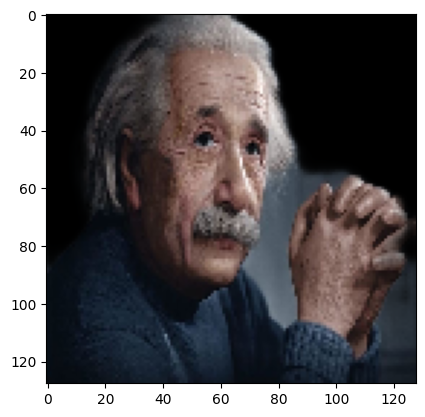

In [44]:
plt.imshow(img/255. * loaded_model.predict(test_image)[0])
plt.show()

## Evaluate, Save and Load Model

In [ ]:
evaluation = model.evaluate(np.array(X_test), y_test_scaled)

In [ ]:
model.save('model_v1.keras')

In [ ]:
loaded_model = tf.keras.models.load_model('model_v1.keras')